## Professor Rating NLP

In [30]:
# install dependencies
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split

## Data exploration

In [31]:
# path of csv file
file_path = "RateMyProfessor-9c.csv"

# Read the CSV file
df = pd.read_csv(file_path)

# Display the first few rows
print(df.head())

# Optional: show basic info about the dataset
print(df.info())

   id  professor_name                                 school_name  \
0   1  Leslie  Looney  University Of Illinois at Urbana-Champaign   
1   2  Leslie  Looney  University Of Illinois at Urbana-Champaign   
2   3  Leslie  Looney  University Of Illinois at Urbana-Champaign   
3   4  Leslie  Looney  University Of Illinois at Urbana-Champaign   
4   5  Leslie  Looney  University Of Illinois at Urbana-Champaign   

        department_name state_name  \
0  Astronomy department         IL   
1  Astronomy department         IL   
2  Astronomy department         IL   
3  Astronomy department         IL   
4  Astronomy department         IL   

                                       tag_professor student_star  \
0  Hilarious (2)  GROUP PROJECTS (2)  Gives good ...          5.0   
1  Hilarious (2)  GROUP PROJECTS (2)  Gives good ...          5.0   
2  Hilarious (2)  GROUP PROJECTS (2)  Gives good ...          4.0   
3  Hilarious (2)  GROUP PROJECTS (2)  Gives good ...          5.0   
4  Hilariou

In [32]:
# Summary statistics for numeric columns
print(df.describe())

                 id  gives_good_feedback        caring     respected  \
count  19994.000000         19994.000000  19994.000000  19994.000000   
mean    9997.500000             0.303091      0.264379      0.279634   
std     5771.914977             0.459606      0.441013      0.448831   
min        1.000000             0.000000      0.000000      0.000000   
25%     4999.250000             0.000000      0.000000      0.000000   
50%     9997.500000             0.000000      0.000000      0.000000   
75%    14995.750000             1.000000      1.000000      1.000000   
max    19994.000000             1.000000      1.000000      1.000000   

       participation_matters  clear_grading_criteria    skip_class  \
count           19994.000000            19994.000000  19994.000000   
mean                0.248725                0.222867      0.279334   
std                 0.432285                0.416180      0.448683   
min                 0.000000                0.000000      0.000000   
2

In [33]:
print(df.columns)
print(df["student_star"].describe())
print(df["student_star"].unique())
print(df["student_star"].value_counts().sort_index())





Index(['id', 'professor_name', 'school_name', 'department_name', 'state_name',
       'tag_professor', 'student_star', 'comments', 'gives_good_feedback',
       'caring', 'respected', 'participation_matters',
       'clear_grading_criteria', 'skip_class', 'amazing_lectures',
       'inspirational', 'tough_grader', 'hilarious', 'get_ready_to_read',
       'lots_of_homework', 'accessible_outside_class', 'lecture_heavy',
       'extra_credit', 'graded_by_few_things', 'group_projects', 'test_heavy',
       'so_many_papers', 'beware_of_pop_quizzes', 'IsCourseOnline'],
      dtype='object')
count     19994
unique       11
top         5.0
freq       7043
Name: student_star, dtype: object
['5.0' '4.0' '4.5' '2.0' '3.5' '1.5' '2.5' '3.0' '1.0' 'STATS'
 'STATISTICS']
student_star
1.0           2594
1.5            911
2.0           1259
2.5            915
3.0           1388
3.5           1116
4.0           2408
4.5           2357
5.0           7043
STATISTICS       1
STATS            2
Name: coun

In [34]:
# List of label columns to summarize
label_cols = [
    'gives_good_feedback', 'caring', 'respected', 'participation_matters',
    'clear_grading_criteria', 'skip_class', 'amazing_lectures',
    'inspirational', 'tough_grader', 'hilarious', 'get_ready_to_read',
    'lots_of_homework', 'accessible_outside_class', 'lecture_heavy',
    'extra_credit', 'graded_by_few_things', 'group_projects', 'test_heavy',
    'so_many_papers', 'beware_of_pop_quizzes', 'IsCourseOnline'
]

# Count how many times each label is marked (assuming 1 = True, 0 = False)
feedback_counts = df[label_cols].sum().sort_values(ascending=False)

# Display nicely
print(feedback_counts)


tough_grader                6742
gives_good_feedback         6060
respected                   5591
skip_class                  5585
caring                      5286
get_ready_to_read           5274
participation_matters       4973
clear_grading_criteria      4456
lecture_heavy               4355
lots_of_homework            4027
amazing_lectures            4004
inspirational               3956
hilarious                   3901
accessible_outside_class    2679
extra_credit                2317
graded_by_few_things        2050
test_heavy                  1967
group_projects              1614
so_many_papers              1535
beware_of_pop_quizzes       1352
IsCourseOnline               402
dtype: int64


## Tokenization

In [35]:
import os
import nltk
from nltk.tokenize import word_tokenize

# (Optional) set a fixed local data folder to avoid permission/path issues on Windows
nltk.data.path.append(os.path.expanduser(r"C:\Users\Owner\nltk_data"))

# Newer NLTK may need BOTH packages:
for pkg in ("punkt", "punkt_tab"):
    nltk.download(pkg, quiet=True)

# Tokenize
df["tokens"] = df["comments"].astype(str).apply(lambda x: word_tokenize(x.lower()))
print(df["tokens"].head())


0    [this, class, is, hard, but, its, a, two-in-on...
1    [definitely, going, to, choose, prof., looney,...
2    [i, overall, enjoyed, this, class, because, th...
3    [yes, it, 's, possible, to, get, an, a, but, y...
4    [professor, looney, has, great, knowledge, in,...
Name: tokens, dtype: object


## Feature Engineering

In [36]:
from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer

# Identity functions so the vectorizers accept pre-tokenized input
identity = lambda x: x

# --- Bag of Words (counts) ---
bow = CountVectorizer(
    tokenizer=identity,          # accept tokens
    preprocessor=identity,
    token_pattern=None,          # disable internal regex
    lowercase=False,             # we already lowercased earlier
    max_features=5000,           # optional: cap vocab size
    min_df=2,                    # optional: drop rare tokens
    ngram_range=(1,1),           # unigrams; change to (1,2) for uni+bi-grams
    binary=False                 # set True for presence/absence features
)
X_bow = bow.fit_transform(df["tokens"])      # sparse matrix (n_docs x n_features)
bow_vocab = bow.get_feature_names_out()      # vocabulary order

# --- TF-IDF ---
tfidf = TfidfVectorizer(
    tokenizer=identity,
    preprocessor=identity,
    token_pattern=None,
    lowercase=False,
    max_features=5000,
    min_df=2,
    ngram_range=(1,1)            # try (1,2) for uni+bi-grams
)
X_tfidf = tfidf.fit_transform(df["tokens"])
tfidf_vocab = tfidf.get_feature_names_out()

# Example: show sizes
print("BOW shape:", X_bow.shape)
print("TFIDF shape:", X_tfidf.shape)

# If you need a (small) preview as a DataFrame:
import pandas as pd
preview = pd.DataFrame(X_bow[:5].toarray(), columns=bow_vocab)
print(preview.iloc[:, :15])  # first 15 features just to peek


BOW shape: (19994, 5000)
TFIDF shape: (19994, 5000)
   !  #  $  %  &  '  ''  'd  'll  'm  're  's  've  (  )
0  0  0  0  0  0  0   0   0    0   0    0   0    0  0  0
1  2  0  0  0  0  0   0   0    0   0    0   1    0  0  0
2  0  0  0  0  0  0   0   0    0   0    0   0    0  0  0
3  0  0  0  0  0  0   0   1    3   0    0   1    0  0  0
4  0  0  0  0  0  0   0   0    0   0    0   0    0  0  0


In [37]:
import numpy as np

df["student_star"] = pd.to_numeric(df["student_star"], errors="coerce")
mask = df["comments"].notna() & df["student_star"].notna()

X = X_tfidf[mask.values]
y_continuous = df.loc[mask, "student_star"]

# Convert to categorical labels (1.0, 1.5, 2.0, 2.5, 3.0, 3.5, 4.0, 4.5, 5.0)
# Round to nearest 0.5
y = np.round(y_continuous * 2) / 2

# Clip to valid range [1.0, 5.0]
y = np.clip(y, 1.0, 5.0)

# Convert to categorical/string labels for classification
y = y.astype(str)

print(f"Target labels: {sorted(y.unique())}")
print(f"Label distribution:\n{y.value_counts().sort_index()}")

Target labels: ['1.0', '1.5', '2.0', '2.5', '3.0', '3.5', '4.0', '4.5', '5.0']
Label distribution:
student_star
1.0    2594
1.5     911
2.0    1259
2.5     915
3.0    1388
3.5    1116
4.0    2408
4.5    2357
5.0    7043
Name: count, dtype: int64


## Training

## Data Balancing

The dataset is imbalanced. Let's apply balancing techniques to improve performance on minority classes.


Original training set class distribution:
student_star
1.0    2073
1.5     727
2.0     997
2.5     729
3.0    1104
3.5     910
4.0    1917
4.5    1880
5.0    5655
Name: count, dtype: int64

Total training samples: 15992


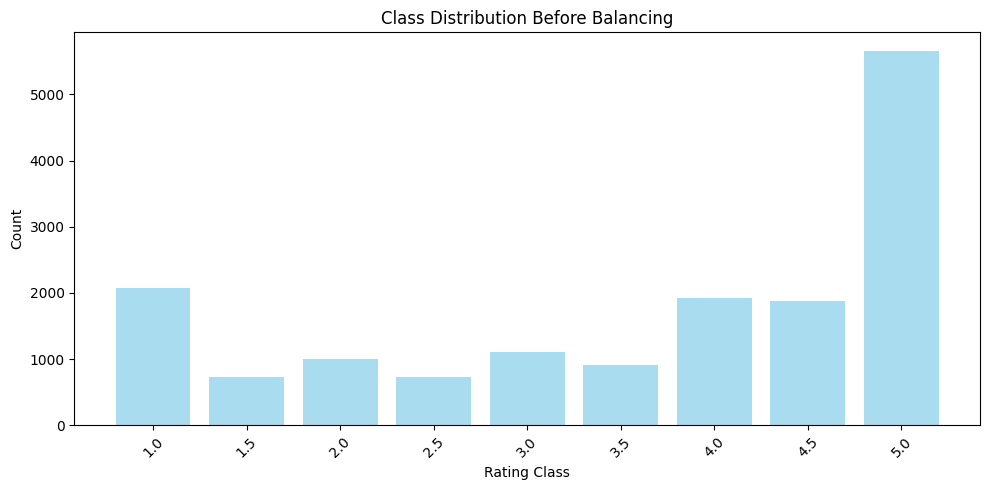

In [38]:
# OPTIONAL: Check class distribution before balancing
# NOTE: This cell requires y_train to exist, so run it AFTER the train/test split (Cell 17)
# You can skip this cell on first run, or run it after Cell 17
try:
    print("Original training set class distribution:")
    print(pd.Series(y_train).value_counts().sort_index())
    print(f"\nTotal training samples: {len(y_train)}")

    # Visualize class distribution
    plt.figure(figsize=(10, 5))
    y_train_counts = pd.Series(y_train).value_counts().sort_index()
    plt.bar(y_train_counts.index, y_train_counts.values, color='skyblue', alpha=0.7)
    plt.xlabel('Rating Class')
    plt.ylabel('Count')
    plt.title('Class Distribution Before Balancing')
    plt.xticks(rotation=45)
    plt.tight_layout()
    plt.show()
except NameError:
    print("Note: y_train doesn't exist yet. Run this cell AFTER the train/test split (Cell 17).")


In [39]:
# train/test split - MUST come BEFORE oversampling
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

print("Train shape:", X_train.shape, "Test shape:", X_test.shape)


Train shape: (15992, 5000) Test shape: (3999, 5000)


## Model Training

Training three models for comparison:
- **Model 1**: Baseline model without data balancing
- **Model 2**: Model with Random Oversampling for balanced classes
- **Model 3**: Model with Data Augmentation for balanced classes


In [40]:
# ============================================
# MODEL 1: Baseline (No Balancing)
# ============================================
from sklearn.linear_model import RidgeClassifier
from sklearn.ensemble import RandomForestClassifier
import numpy as np

print("=" * 50)
print("MODEL 1: Training Baseline Model (No Balancing)")
print("=" * 50)
print(f"Training data shape: {X_train.shape}")
print(f"Using original unbalanced training data")

# Train Model 1 with original data
model1 = RidgeClassifier(alpha=1.0, random_state=42)
model1.fit(X_train, y_train)  # Using original unbalanced data
y_pred_model1 = model1.predict(X_test)

print(f"\nModel 1 - Predicted labels: {sorted(np.unique(y_pred_model1))}")
print(f"Model 1 - Prediction distribution:")
print(pd.Series(y_pred_model1).value_counts().sort_index())


MODEL 1: Training Baseline Model (No Balancing)
Training data shape: (15992, 5000)
Using original unbalanced training data

Model 1 - Predicted labels: ['1.0', '1.5', '2.0', '2.5', '3.0', '3.5', '4.0', '4.5', '5.0']
Model 1 - Prediction distribution:
1.0     722
1.5      29
2.0     103
2.5      50
3.0     136
3.5      65
4.0     341
4.5     208
5.0    2345
Name: count, dtype: int64


## Individual Model Evaluation

Evaluating each model separately:


MODEL 1 EVALUATION (Baseline - No Balancing)

Classification Accuracy: 0.431
Accuracy within ±0.5-star margin: 0.618
Accuracy within ±1.0-star margin: 0.781

Classification Report:
              precision    recall  f1-score   support

         1.0       0.48      0.66      0.56       521
         1.5       0.10      0.02      0.03       184
         2.0       0.17      0.07      0.10       262
         2.5       0.18      0.05      0.08       186
         3.0       0.19      0.09      0.12       284
         3.5       0.12      0.04      0.06       206
         4.0       0.20      0.14      0.16       491
         4.5       0.16      0.07      0.10       477
         5.0       0.52      0.87      0.65      1388

    accuracy                           0.43      3999
   macro avg       0.24      0.22      0.21      3999
weighted avg       0.33      0.43      0.35      3999



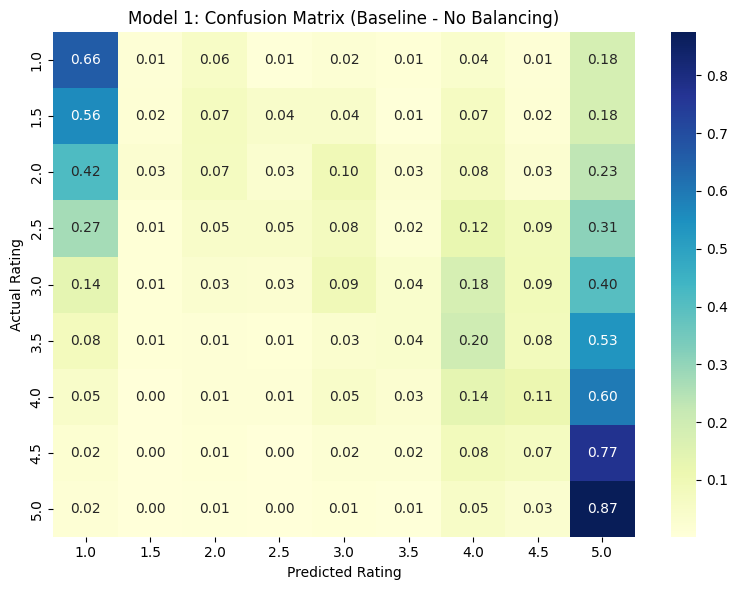

In [41]:
# ============================================
# EVALUATE MODEL 1 (Baseline - No Balancing)
# ============================================
import numpy as np
import pandas as pd
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
import matplotlib.pyplot as plt
import seaborn as sns

print("=" * 50)
print("MODEL 1 EVALUATION (Baseline - No Balancing)")
print("=" * 50)

# Get all possible classes
all_classes = [f"{x:.1f}" for x in np.arange(1.0, 5.1, 0.5)]

# Calculate metrics for Model 1
accuracy_model1 = accuracy_score(y_test, y_pred_model1)
y_test_numeric = np.array([float(x) for x in y_test])
y_pred_model1_numeric = np.array([float(x) for x in y_pred_model1])

within_half_model1 = np.abs(y_pred_model1_numeric - y_test_numeric) <= 0.5
within_one_model1 = np.abs(y_pred_model1_numeric - y_test_numeric) <= 1.0
acc_within_half_model1 = np.mean(within_half_model1)
acc_within_one_model1 = np.mean(within_one_model1)

print(f"\nClassification Accuracy: {accuracy_model1:.3f}")
print(f"Accuracy within ±0.5-star margin: {acc_within_half_model1:.3f}")
print(f"Accuracy within ±1.0-star margin: {acc_within_one_model1:.3f}")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_model1, labels=all_classes, zero_division=0))

# Confusion matrix for Model 1
cm_model1 = confusion_matrix(y_test, y_pred_model1, labels=all_classes, normalize='true')
plt.figure(figsize=(8, 6))
sns.heatmap(cm_model1, annot=True, fmt=".2f", cmap="YlGnBu", 
            xticklabels=all_classes, yticklabels=all_classes)
plt.xlabel("Predicted Rating")
plt.ylabel("Actual Rating")
plt.title("Model 1: Confusion Matrix (Baseline - No Balancing)")
plt.tight_layout()
plt.show()


MODEL 2 EVALUATION (With Random Oversampling)

Classification Accuracy: 0.308
Accuracy within ±0.5-star margin: 0.553
Accuracy within ±1.0-star margin: 0.720

Classification Report:
              precision    recall  f1-score   support

         1.0       0.41      0.50      0.45       521
         1.5       0.11      0.16      0.13       184
         2.0       0.11      0.13      0.12       262
         2.5       0.09      0.15      0.11       186
         3.0       0.12      0.14      0.13       284
         3.5       0.07      0.13      0.09       206
         4.0       0.19      0.15      0.17       491
         4.5       0.17      0.16      0.17       477
         5.0       0.68      0.48      0.56      1388

    accuracy                           0.31      3999
   macro avg       0.22      0.22      0.22      3999
weighted avg       0.36      0.31      0.33      3999



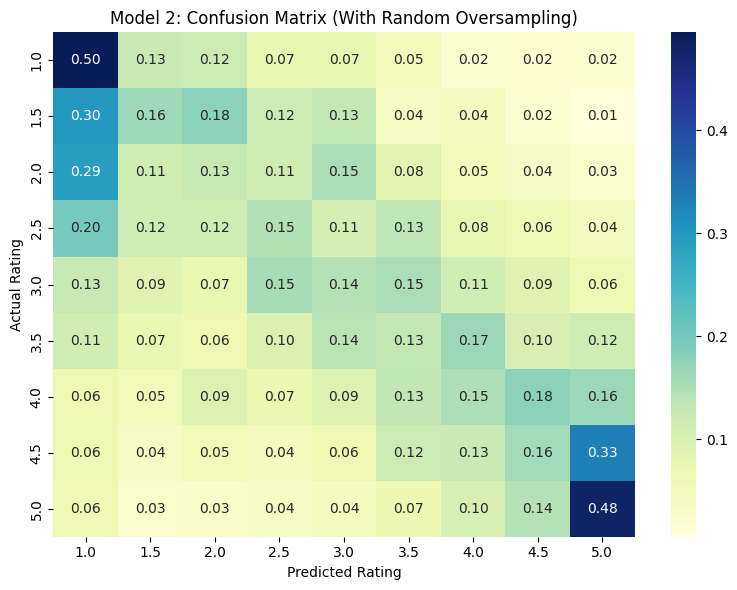

In [42]:
# ============================================
# EVALUATE MODEL 2 (With Random Oversampling)
# ============================================
print("=" * 50)
print("MODEL 2 EVALUATION (With Random Oversampling)")
print("=" * 50)

# Check if Model 2 has been trained
try:
    # Calculate metrics for Model 2
    accuracy_model2 = accuracy_score(y_test, y_pred_model2)
    y_pred_model2_numeric = np.array([float(x) for x in y_pred_model2])

    within_half_model2 = np.abs(y_pred_model2_numeric - y_test_numeric) <= 0.5
    within_one_model2 = np.abs(y_pred_model2_numeric - y_test_numeric) <= 1.0
    acc_within_half_model2 = np.mean(within_half_model2)
    acc_within_one_model2 = np.mean(within_one_model2)

    print(f"\nClassification Accuracy: {accuracy_model2:.3f}")
    print(f"Accuracy within ±0.5-star margin: {acc_within_half_model2:.3f}")
    print(f"Accuracy within ±1.0-star margin: {acc_within_one_model2:.3f}")

    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_model2, labels=all_classes, zero_division=0))

    # Confusion matrix for Model 2
    cm_model2 = confusion_matrix(y_test, y_pred_model2, labels=all_classes, normalize='true')
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_model2, annot=True, fmt=".2f", cmap="YlGnBu", 
                xticklabels=all_classes, yticklabels=all_classes)
    plt.xlabel("Predicted Rating")
    plt.ylabel("Actual Rating")
    plt.title("Model 2: Confusion Matrix (With Random Oversampling)")
    plt.tight_layout()
    plt.show()
    
except NameError:
    print("\n⚠️  ERROR: Model 2 predictions (y_pred_model2) not found!")
    print("\nPlease ensure you have run the following cells in order:")
    print("  1. Cell 23: Random Oversampling (creates X_train_ros, y_train_ros)")
    print("  2. Cell 24: Model 2 Training (creates model2 and y_pred_model2)")
    print("\nThen re-run this evaluation cell (Cell 22).")
except Exception as e:
    print(f"\n⚠️  ERROR: {type(e).__name__}: {e}")
    print("\nPlease check that all prerequisite cells have been run.")


In [43]:
# Install imbalanced-learn if not already installed
try:
    from imblearn.over_sampling import RandomOverSampler
    from imblearn.under_sampling import RandomUnderSampler
except ImportError:
    import subprocess
    import sys
    subprocess.check_call([sys.executable, "-m", "pip", "install", "imbalanced-learn"])
    from imblearn.over_sampling import RandomOverSampler
    from imblearn.under_sampling import RandomUnderSampler

# Random Oversampling - Apply to training data ONLY (not test data!)
# This MUST come AFTER the train/test split
print("\n=== Applying Random Oversampling ===")
ros = RandomOverSampler(random_state=42)
X_train_ros, y_train_ros = ros.fit_resample(X_train, y_train)

print(f"Before oversampling: {len(y_train)} samples")
print(f"After oversampling: {len(y_train_ros)} samples")
print(f"\nClass distribution after oversampling:")
print(pd.Series(y_train_ros).value_counts().sort_index())


=== Applying Random Oversampling ===
Before oversampling: 15992 samples
After oversampling: 50895 samples

Class distribution after oversampling:
student_star
1.0    5655
1.5    5655
2.0    5655
2.5    5655
3.0    5655
3.5    5655
4.0    5655
4.5    5655
5.0    5655
Name: count, dtype: int64


In [44]:
# ============================================
# MODEL 2: With Random Oversampling
# ============================================
print("\n" + "=" * 50)
print("MODEL 2: Training Model with Random Oversampling")
print("=" * 50)

# Check if oversampling has been applied and train Model 2
try:
    # Verify that oversampled data exists by accessing them
    _ = X_train_ros.shape
    _ = y_train_ros.shape
    
    print(f"Training data shape before balancing: {X_train.shape}")
    print(f"Training data shape after balancing: {X_train_ros.shape}")
    print(f"Using Random Oversampling for balanced classes")
    
    # Train Model 2 with oversampled data
    from sklearn.linear_model import RidgeClassifier
    import numpy as np
    import pandas as pd
    
    model2 = RidgeClassifier(alpha=1.0, random_state=42)
    model2.fit(X_train_ros, y_train_ros)  # Using oversampled training data
    y_pred_model2 = model2.predict(X_test)
    
    print(f"\nModel 2 - Predicted labels: {sorted(np.unique(y_pred_model2))}")
    print(f"Model 2 - Prediction distribution:")
    print(pd.Series(y_pred_model2).value_counts().sort_index())
    
    print(f"\n✓ Model 2 training completed successfully!")
    print(f"✓ Model 2 predictions (y_pred_model2) are ready for evaluation.")
    
except NameError as e:
    print(f"\n⚠️  ERROR: Oversampled data not found!")
    print("\nPlease ensure you have run the following cells in order:")
    print("  1. Train/Test Split cell (creates X_train, X_test, y_train, y_test)")
    print("  2. Random Oversampling cell (creates X_train_ros, y_train_ros)")
    print("  3. This Model 2 Training cell")
    print("\nThen re-run this cell.")
except Exception as e:
    print(f"\n⚠️  ERROR: {type(e).__name__}: {e}")
    print("\nPlease check that all prerequisite cells have been run.")


MODEL 2: Training Model with Random Oversampling
Training data shape before balancing: (15992, 5000)
Training data shape after balancing: (50895, 5000)
Using Random Oversampling for balanced classes

Model 2 - Predicted labels: ['1.0', '1.5', '2.0', '2.5', '3.0', '3.5', '4.0', '4.5', '5.0']
Model 2 - Prediction distribution:
1.0    634
1.5    270
2.0    299
2.5    289
3.0    331
3.5    370
4.0    389
4.5    444
5.0    973
Name: count, dtype: int64

✓ Model 2 training completed successfully!
✓ Model 2 predictions (y_pred_model2) are ready for evaluation.


## Model 3: Data Augmentation

Training Model 3 with data augmentation techniques instead of oversampling.


In [45]:
# ============================================
# DATA AUGMENTATION FOR MODEL 3
# ============================================
# Apply text augmentation techniques to increase data diversity
# This creates new variations of existing text data rather than duplicating samples

import random
import numpy as np
from nltk.corpus import wordnet
import nltk
import pandas as pd

print("=" * 50)
print("APPLYING DATA AUGMENTATION FOR MODEL 3")
print("=" * 50)

# Download required NLTK data
try:
    nltk.data.find('corpora/wordnet')
except LookupError:
    nltk.download('wordnet', quiet=True)
    nltk.download('omw-1.4', quiet=True)

# Get original text data for training set
# We'll use the same mask and recreate the split to get training indices
mask = df["comments"].notna() & df["student_star"].notna()
df_filtered = df[mask.values].copy().reset_index(drop=True)

# IMPORTANT: y is already filtered from df using mask, so we should NOT apply mask again
# y was created from df.loc[mask, "student_star"], so it's already aligned with filtered data
# Verify alignment to prevent IndexError: "Boolean index has wrong length: 19994 instead of 19991"
if len(y) != len(df_filtered):
    raise ValueError(
        f"LENGTH MISMATCH ERROR!\n"
        f"   y has {len(y)} entries but df_filtered has {len(df_filtered)} entries.\n"
        f"   This indicates y was created with a different mask or the data has changed.\n"
        f"   Please re-run the data preparation cells that create y (usually after TF-IDF)."
    )

# Use y directly - it's already filtered and aligned with df_filtered
y_filtered = np.array(y) if not isinstance(y, np.ndarray) else y

# Recreate train/test split with indices (same random_state=42 as before)
from sklearn.model_selection import train_test_split
indices_array = np.arange(len(y_filtered))
train_idx, _ = train_test_split(
    indices_array, test_size=0.2, random_state=42, stratify=y_filtered
)

# Get original text comments for training set
train_comments = df_filtered.iloc[train_idx]["comments"].values
train_labels = y_filtered[train_idx]

print(f"\nOriginal training data: {len(train_comments)} samples")

def get_synonyms(word):
    """Get synonyms for a word using WordNet."""
    synonyms = set()
    for syn in wordnet.synsets(word):
        for lemma in syn.lemmas():
            synonym = lemma.name().replace('_', ' ').lower()
            if synonym != word and len(synonym.split()) == 1:
                synonyms.add(synonym)
    return list(synonyms)

def augment_text(text, num_augmentations=1, aug_prob=0.3):
    """
    Apply text augmentation techniques:
    - Synonym replacement (with probability aug_prob)
    - Random word deletion (with probability aug_prob/2)
    """
    if pd.isna(text) or not isinstance(text, str):
        return text
    
    words = text.lower().split()
    if len(words) < 2:
        return text
    
    augmented_texts = []
    for _ in range(num_augmentations):
        new_words = words.copy()
        
        # Synonym replacement
        if random.random() < aug_prob:
            num_replacements = max(1, int(len(new_words) * aug_prob))
            indices = random.sample(range(len(new_words)), min(num_replacements, len(new_words)))
            for idx in indices:
                word = new_words[idx].strip('.,!?;:()[]{}')
                synonyms = get_synonyms(word)
                if synonyms:
                    synonym = random.choice(synonyms)
                    new_words[idx] = new_words[idx].replace(word, synonym)
        
        # Random word deletion (sparse)
        if random.random() < aug_prob / 2 and len(new_words) > 3:
            num_deletions = max(1, int(len(new_words) * aug_prob / 3))
            indices_to_delete = sorted(random.sample(range(len(new_words)), min(num_deletions, len(new_words))), reverse=True)
            for idx in indices_to_delete:
                del new_words[idx]
        
        augmented_texts.append(' '.join(new_words))
    
    return augmented_texts

# Apply augmentation to minority classes
# Augment classes with fewer samples to balance the dataset
class_counts = pd.Series(train_labels).value_counts()
max_count = class_counts.max()
augmentation_factor = {label: max(1, int(max_count / count)) for label, count in class_counts.items()}

print(f"\nClass distribution before augmentation:")
print(pd.Series(train_labels).value_counts().sort_index())

augmented_comments = []
augmented_labels = []

for comment, label in zip(train_comments, train_labels):
    # Always include original
    augmented_comments.append(str(comment))
    augmented_labels.append(label)
    
    # Add augmented versions for minority classes
    if label in augmentation_factor:
        num_aug = min(augmentation_factor[label] - 1, 3)  # Cap at 3 augmentations per sample
        if num_aug > 0:
            aug_texts = augment_text(comment, num_augmentations=num_aug)
            if isinstance(aug_texts, list):
                for aug_text in aug_texts:
                    augmented_comments.append(aug_text)
                    augmented_labels.append(label)
            elif aug_texts:
                augmented_comments.append(aug_texts)
                augmented_labels.append(label)

print(f"\nAfter augmentation: {len(augmented_comments)} samples")
print(f"\nClass distribution after augmentation:")
print(pd.Series(augmented_labels).value_counts().sort_index())

# Re-tokenize augmented comments
from nltk.tokenize import word_tokenize
augmented_tokens = [word_tokenize(str(comment).lower()) for comment in augmented_comments]

# Re-vectorize using the same TF-IDF vectorizer (expects tokenized input)
# The tfidf vectorizer was fit with tokenizer=identity, so it expects pre-tokenized lists
X_train_aug = tfidf.transform(augmented_tokens)
# Convert labels to string format to match y_train
y_train_aug = np.array([str(float(label)) if not isinstance(label, str) else label for label in augmented_labels])

print(f"\nAugmented training data shape: {X_train_aug.shape}")
print(f"✓ Data augmentation completed!")
print(f"✓ Ready to train Model 3 with augmented data.")


APPLYING DATA AUGMENTATION FOR MODEL 3

Original training data: 15992 samples

Class distribution before augmentation:
1.0    2075
1.5     729
2.0    1007
2.5     732
3.0    1110
3.5     893
4.0    1926
4.5    1886
5.0    5634
Name: count, dtype: int64

After augmentation: 35230 samples

Class distribution after augmentation:
1.0    4150
1.5    2902
2.0    4014
2.5    2920
3.0    4422
3.5    3564
4.0    3852
4.5    3772
5.0    5634
Name: count, dtype: int64

Augmented training data shape: (35230, 5000)
✓ Data augmentation completed!
✓ Ready to train Model 3 with augmented data.


In [46]:
# ============================================
# MODEL 3: With Data Augmentation
# ============================================
print("\n" + "=" * 50)
print("MODEL 3: Training Model with Data Augmentation")
print("=" * 50)

# Check if data augmentation has been applied
try:
    # Verify that augmented data exists
    _ = X_train_aug.shape
    _ = len(y_train_aug)
    
    print(f"Training data shape before augmentation: {X_train.shape}")
    print(f"Training data shape after augmentation: {X_train_aug.shape}")
    print(f"Using Data Augmentation for balanced classes")
    
    # Train Model 3 with augmented data
    from sklearn.linear_model import RidgeClassifier
    import numpy as np
    import pandas as pd
    
    model3 = RidgeClassifier(alpha=1.0, random_state=42)
    model3.fit(X_train_aug, y_train_aug)  # Using augmented training data
    y_pred_model3 = model3.predict(X_test)
    
    print(f"\nModel 3 - Predicted labels: {sorted(np.unique(y_pred_model3))}")
    print(f"Model 3 - Prediction distribution:")
    print(pd.Series(y_pred_model3).value_counts().sort_index())
    
    print(f"\n✓ Model 3 training completed successfully!")
    print(f"✓ Model 3 predictions (y_pred_model3) are ready for evaluation.")
    
except NameError:
    print("\n⚠️  ERROR: Augmented data not found!")
    print("\nPlease ensure you have run the following cells in order:")
    print("  1. Train/Test Split cell (creates X_train, X_test, y_train, y_test)")
    print("  2. Data Augmentation cell (creates X_train_aug, y_train_aug)")
    print("  3. This Model 3 Training cell")
    print("\nThen re-run this cell.")
except Exception as e:
    print(f"\n⚠️  ERROR: {type(e).__name__}: {e}")
    print("\nPlease check that all prerequisite cells have been run.")



MODEL 3: Training Model with Data Augmentation
Training data shape before augmentation: (15992, 5000)
Training data shape after augmentation: (35230, 5000)
Using Data Augmentation for balanced classes

Model 3 - Predicted labels: ['1.0', '1.5', '2.0', '2.5', '3.0', '3.5', '4.0', '4.5', '5.0']
Model 3 - Prediction distribution:
1.0     675
1.5     173
2.0     281
2.5     185
3.0     381
3.5     279
4.0     336
4.5     340
5.0    1349
Name: count, dtype: int64

✓ Model 3 training completed successfully!
✓ Model 3 predictions (y_pred_model3) are ready for evaluation.


MODEL 3 EVALUATION (With Data Augmentation)

Classification Accuracy: 0.626
Accuracy within ±0.5-star margin: 0.751
Accuracy within ±1.0-star margin: 0.849

Classification Report:
              precision    recall  f1-score   support

         1.0       0.59      0.77      0.67       521
         1.5       0.60      0.56      0.58       184
         2.0       0.53      0.57      0.55       262
         2.5       0.58      0.58      0.58       186
         3.0       0.48      0.64      0.55       284
         3.5       0.47      0.63      0.54       206
         4.0       0.64      0.44      0.52       491
         4.5       0.59      0.42      0.49       477
         5.0       0.75      0.73      0.74      1388

    accuracy                           0.63      3999
   macro avg       0.58      0.59      0.58      3999
weighted avg       0.63      0.63      0.62      3999



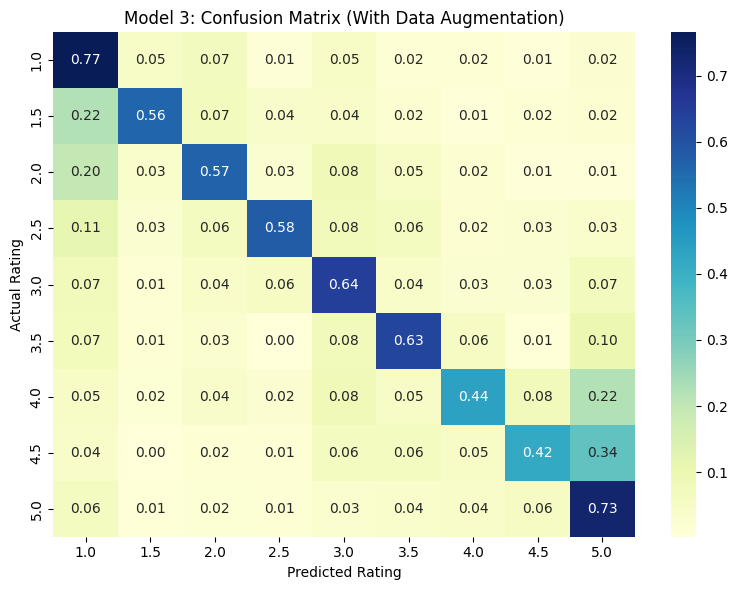

In [47]:
# ============================================
# EVALUATE MODEL 3 (With Data Augmentation)
# ============================================
print("=" * 50)
print("MODEL 3 EVALUATION (With Data Augmentation)")
print("=" * 50)

# Check if Model 3 has been trained
try:
    import pandas as pd
    from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # Get all possible classes
    all_classes = [f"{x:.1f}" for x in np.arange(1.0, 5.1, 0.5)]
    
    # Calculate metrics for Model 3
    accuracy_model3 = accuracy_score(y_test, y_pred_model3)
    y_test_numeric = np.array([float(x) for x in y_test])
    y_pred_model3_numeric = np.array([float(x) for x in y_pred_model3])
    
    within_half_model3 = np.abs(y_pred_model3_numeric - y_test_numeric) <= 0.5
    within_one_model3 = np.abs(y_pred_model3_numeric - y_test_numeric) <= 1.0
    acc_within_half_model3 = np.mean(within_half_model3)
    acc_within_one_model3 = np.mean(within_one_model3)
    
    print(f"\nClassification Accuracy: {accuracy_model3:.3f}")
    print(f"Accuracy within ±0.5-star margin: {acc_within_half_model3:.3f}")
    print(f"Accuracy within ±1.0-star margin: {acc_within_one_model3:.3f}")
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_model3, labels=all_classes, zero_division=0))
    
    # Confusion matrix for Model 3
    cm_model3 = confusion_matrix(y_test, y_pred_model3, labels=all_classes, normalize='true')
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_model3, annot=True, fmt=".2f", cmap="YlGnBu", 
                xticklabels=all_classes, yticklabels=all_classes)
    plt.xlabel("Predicted Rating")
    plt.ylabel("Actual Rating")
    plt.title("Model 3: Confusion Matrix (With Data Augmentation)")
    plt.tight_layout()
    plt.show()
    
except NameError:
    print("\n⚠️  ERROR: Model 3 predictions (y_pred_model3) not found!")
    print("\nPlease ensure you have run the following cells in order:")
    print("  1. Data Augmentation cell (creates X_train_aug, y_train_aug)")
    print("  2. Model 3 Training cell (creates model3 and y_pred_model3)")
    print("  3. This evaluation cell")
    print("\nThen re-run this cell.")
except Exception as e:
    print(f"\n⚠️  ERROR: {type(e).__name__}: {e}")
    print("\nPlease check that all prerequisite cells have been run.")



In [48]:
# ============================================
# MODEL 4: XGBoost with Data Augmentation
# ============================================
print("\n" + "=" * 50)
print("MODEL 4: Training XGBoost Model with Data Augmentation")
print("=" * 50)

# Check if data augmentation has been applied
try:
    # Verify that augmented data exists
    _ = X_train_aug.shape
    _ = len(y_train_aug)
    
    print(f"Training data shape before augmentation: {X_train.shape}")
    print(f"Training data shape after augmentation: {X_train_aug.shape}")
    print(f"Using XGBoost with Augmented Data")
    
    # Install xgboost if not already installed
    try:
        import xgboost as xgb
    except ImportError:
        import subprocess
        import sys
        subprocess.check_call([sys.executable, "-m", "pip", "install", "xgboost"])
        import xgboost as xgb
    
    # Train Model 4 with XGBoost using augmented data
    import numpy as np
    import pandas as pd
    
    # XGBoost requires label encoding for multi-class classification
    # Convert string labels to integer labels
    from sklearn.preprocessing import LabelEncoder
    le = LabelEncoder()
    y_train_aug_encoded = le.fit_transform(y_train_aug)
    
    # Create XGBoost classifier
    model4 = xgb.XGBClassifier(
        objective='multi:softprob',
        num_class=len(np.unique(y_train_aug_encoded)),
        random_state=42,
        n_estimators=100,
        max_depth=6,
        learning_rate=0.1,
        subsample=0.8,
        colsample_bytree=0.8,
        eval_metric='mlogloss'
    )
    
    model4.fit(X_train_aug, y_train_aug_encoded)
    
    # Make predictions and convert back to string labels
    y_pred_model4_encoded = model4.predict(X_test)
    y_pred_model4 = le.inverse_transform(y_pred_model4_encoded)
    
    print(f"\nModel 4 - Predicted labels: {sorted(np.unique(y_pred_model4))}")
    print(f"Model 4 - Prediction distribution:")
    print(pd.Series(y_pred_model4).value_counts().sort_index())
    
    print(f"\n✓ Model 4 (XGBoost) training completed successfully!")
    print(f"✓ Model 4 predictions (y_pred_model4) are ready for evaluation.")
    
except NameError:
    print("\n⚠️  ERROR: Augmented data not found!")
    print("\nPlease ensure you have run the following cells in order:")
    print("  1. Train/Test Split cell (creates X_train, X_test, y_train, y_test)")
    print("  2. Data Augmentation cell (creates X_train_aug, y_train_aug)")
    print("  3. This Model 4 Training cell")
    print("\nThen re-run this cell.")
except Exception as e:
    print(f"\n⚠️  ERROR: {type(e).__name__}: {e}")
    print("\nPlease check that all prerequisite cells have been run.")



MODEL 4: Training XGBoost Model with Data Augmentation
Training data shape before augmentation: (15992, 5000)
Training data shape after augmentation: (35230, 5000)
Using XGBoost with Augmented Data

Model 4 - Predicted labels: ['1.0', '1.5', '2.0', '2.5', '3.0', '3.5', '4.0', '4.5', '5.0']
Model 4 - Prediction distribution:
1.0     788
1.5     133
2.0     270
2.5     140
3.0     417
3.5     171
4.0     395
4.5     288
5.0    1397
Name: count, dtype: int64

✓ Model 4 (XGBoost) training completed successfully!
✓ Model 4 predictions (y_pred_model4) are ready for evaluation.


MODEL 4 EVALUATION (XGBoost with Data Augmentation)

Classification Accuracy: 0.680
Accuracy within ±0.5-star margin: 0.765
Accuracy within ±1.0-star margin: 0.851

Classification Report:
              precision    recall  f1-score   support

         1.0       0.56      0.84      0.67       521
         1.5       0.86      0.62      0.72       184
         2.0       0.62      0.64      0.63       262
         2.5       0.86      0.65      0.74       186
         3.0       0.47      0.69      0.56       284
         3.5       0.75      0.62      0.68       206
         4.0       0.68      0.55      0.61       491
         4.5       0.79      0.48      0.60       477
         5.0       0.76      0.76      0.76      1388

    accuracy                           0.68      3999
   macro avg       0.71      0.65      0.66      3999
weighted avg       0.71      0.68      0.68      3999



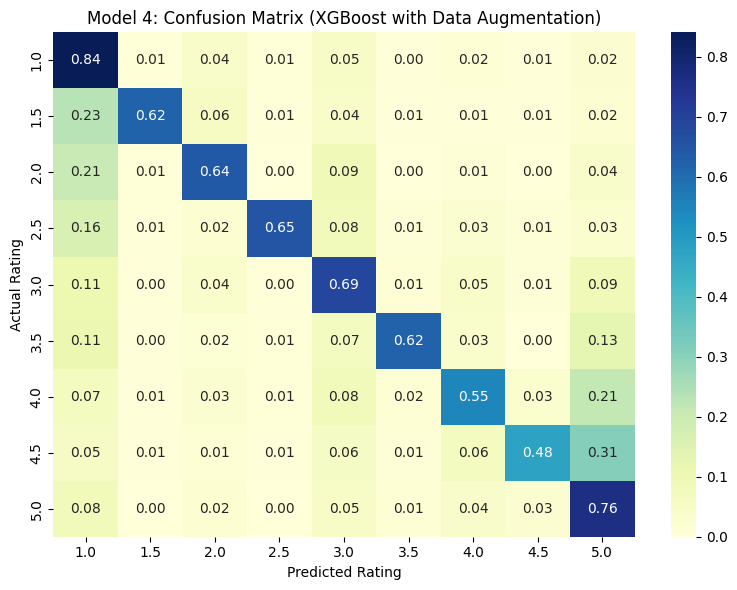

In [49]:
# ============================================
# EVALUATE MODEL 4 (XGBoost with Data Augmentation)
# ============================================
print("=" * 50)
print("MODEL 4 EVALUATION (XGBoost with Data Augmentation)")
print("=" * 50)

# Check if Model 4 has been trained
try:
    import pandas as pd
    from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # Get all possible classes
    all_classes = [f"{x:.1f}" for x in np.arange(1.0, 5.1, 0.5)]
    
    # Calculate metrics for Model 4
    accuracy_model4 = accuracy_score(y_test, y_pred_model4)
    y_test_numeric = np.array([float(x) for x in y_test])
    y_pred_model4_numeric = np.array([float(x) for x in y_pred_model4])
    
    within_half_model4 = np.abs(y_pred_model4_numeric - y_test_numeric) <= 0.5
    within_one_model4 = np.abs(y_pred_model4_numeric - y_test_numeric) <= 1.0
    acc_within_half_model4 = np.mean(within_half_model4)
    acc_within_one_model4 = np.mean(within_one_model4)
    
    print(f"\nClassification Accuracy: {accuracy_model4:.3f}")
    print(f"Accuracy within ±0.5-star margin: {acc_within_half_model4:.3f}")
    print(f"Accuracy within ±1.0-star margin: {acc_within_one_model4:.3f}")
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_model4, labels=all_classes, zero_division=0))
    
    # Confusion matrix for Model 4
    cm_model4 = confusion_matrix(y_test, y_pred_model4, labels=all_classes, normalize='true')
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_model4, annot=True, fmt=".2f", cmap="YlGnBu",
                xticklabels=all_classes, yticklabels=all_classes)
    plt.xlabel("Predicted Rating")
    plt.ylabel("Actual Rating")
    plt.title("Model 4: Confusion Matrix (XGBoost with Data Augmentation)")
    plt.tight_layout()
    plt.show()
    
except NameError:
    print("\n⚠️  ERROR: Model 4 predictions (y_pred_model4) not found!")
    print("\nPlease ensure you have run the following cells in order:")
    print("  1. Data Augmentation cell (creates X_train_aug, y_train_aug)")
    print("  2. Model 4 Training cell (creates model4 and y_pred_model4)")
    print("  3. This evaluation cell")
    print("\nThen re-run this cell.")
except Exception as e:
    print(f"\n⚠️  ERROR: {type(e).__name__}: {e}")
    print("\nPlease check that all prerequisite cells have been run.")


In [50]:
# ============================================
# MODEL 5: Random Forest with Data Augmentation
# ============================================
print("\n" + "=" * 50)
print("MODEL 5: Training Random Forest Model with Data Augmentation")
print("=" * 50)

# Check if data augmentation has been applied
try:
    # Verify that augmented data exists
    _ = X_train_aug.shape
    _ = len(y_train_aug)
    
    print(f"Training data shape before augmentation: {X_train.shape}")
    print(f"Training data shape after augmentation: {X_train_aug.shape}")
    print(f"Using Random Forest with Augmented Data")
    
    # Train Model 5 with Random Forest using augmented data
    from sklearn.ensemble import RandomForestClassifier
    import numpy as np
    import pandas as pd
    
    # Create Random Forest classifier
    model5 = RandomForestClassifier(
        n_estimators=100,
        max_depth=20,
        min_samples_split=5,
        min_samples_leaf=2,
        random_state=42,
        n_jobs=-1,
        class_weight='balanced'
    )
    
    model5.fit(X_train_aug, y_train_aug)
    y_pred_model5 = model5.predict(X_test)
    
    print(f"\nModel 5 - Predicted labels: {sorted(np.unique(y_pred_model5))}")
    print(f"Model 5 - Prediction distribution:")
    print(pd.Series(y_pred_model5).value_counts().sort_index())
    
    print(f"\n✓ Model 5 (Random Forest) training completed successfully!")
    print(f"✓ Model 5 predictions (y_pred_model5) are ready for evaluation.")
    
except NameError:
    print("\n⚠️  ERROR: Augmented data not found!")
    print("\nPlease ensure you have run the following cells in order:")
    print("  1. Train/Test Split cell (creates X_train, X_test, y_train, y_test)")
    print("  2. Data Augmentation cell (creates X_train_aug, y_train_aug)")
    print("  3. This Model 5 Training cell")
    print("\nThen re-run this cell.")
except Exception as e:
    print(f"\n⚠️  ERROR: {type(e).__name__}: {e}")
    print("\nPlease check that all prerequisite cells have been run.")



MODEL 5: Training Random Forest Model with Data Augmentation
Training data shape before augmentation: (15992, 5000)
Training data shape after augmentation: (35230, 5000)
Using Random Forest with Augmented Data

Model 5 - Predicted labels: ['1.0', '1.5', '2.0', '2.5', '3.0', '3.5', '4.0', '4.5', '5.0']
Model 5 - Prediction distribution:
1.0     833
1.5     188
2.0     244
2.5     173
3.0     316
3.5     244
4.0     417
4.5     393
5.0    1191
Name: count, dtype: int64

✓ Model 5 (Random Forest) training completed successfully!
✓ Model 5 predictions (y_pred_model5) are ready for evaluation.


MODEL 5 EVALUATION (Random Forest with Data Augmentation)

Classification Accuracy: 0.690
Accuracy within ±0.5-star margin: 0.775
Accuracy within ±1.0-star margin: 0.847

Classification Report:
              precision    recall  f1-score   support

         1.0       0.52      0.83      0.64       521
         1.5       0.70      0.72      0.71       184
         2.0       0.73      0.68      0.70       262
         2.5       0.76      0.71      0.74       186
         3.0       0.61      0.68      0.64       284
         3.5       0.59      0.70      0.64       206
         4.0       0.72      0.62      0.67       491
         4.5       0.71      0.58      0.64       477
         5.0       0.81      0.70      0.75      1388

    accuracy                           0.69      3999
   macro avg       0.68      0.69      0.68      3999
weighted avg       0.71      0.69      0.69      3999



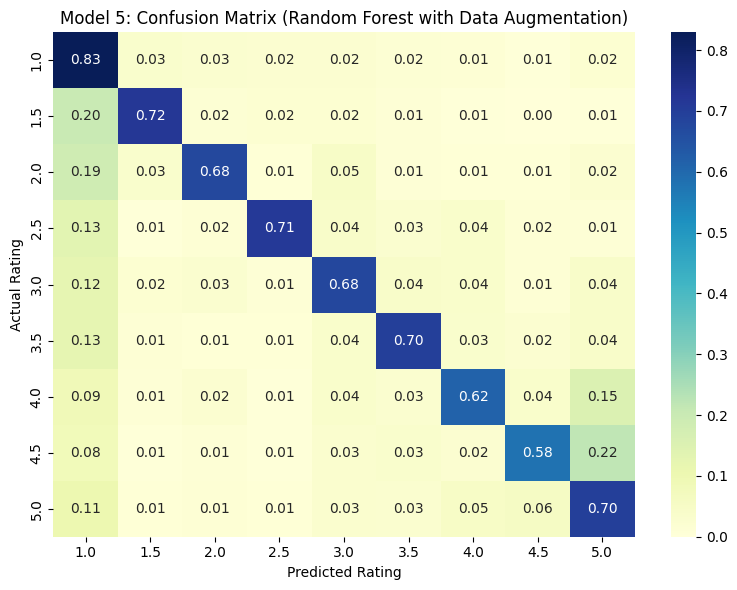

In [51]:
# ============================================
# EVALUATE MODEL 5 (Random Forest with Data Augmentation)
# ============================================
print("=" * 50)
print("MODEL 5 EVALUATION (Random Forest with Data Augmentation)")
print("=" * 50)

# Check if Model 5 has been trained
try:
    import pandas as pd
    from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # Get all possible classes
    all_classes = [f"{x:.1f}" for x in np.arange(1.0, 5.1, 0.5)]
    
    # Calculate metrics for Model 5
    accuracy_model5 = accuracy_score(y_test, y_pred_model5)
    y_test_numeric = np.array([float(x) for x in y_test])
    y_pred_model5_numeric = np.array([float(x) for x in y_pred_model5])
    
    within_half_model5 = np.abs(y_pred_model5_numeric - y_test_numeric) <= 0.5
    within_one_model5 = np.abs(y_pred_model5_numeric - y_test_numeric) <= 1.0
    acc_within_half_model5 = np.mean(within_half_model5)
    acc_within_one_model5 = np.mean(within_one_model5)
    
    print(f"\nClassification Accuracy: {accuracy_model5:.3f}")
    print(f"Accuracy within ±0.5-star margin: {acc_within_half_model5:.3f}")
    print(f"Accuracy within ±1.0-star margin: {acc_within_one_model5:.3f}")
    
    print("\nClassification Report:")
    print(classification_report(y_test, y_pred_model5, labels=all_classes, zero_division=0))
    
    # Confusion matrix for Model 5
    cm_model5 = confusion_matrix(y_test, y_pred_model5, labels=all_classes, normalize='true')
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_model5, annot=True, fmt=".2f", cmap="YlGnBu",
                xticklabels=all_classes, yticklabels=all_classes)
    plt.xlabel("Predicted Rating")
    plt.ylabel("Actual Rating")
    plt.title("Model 5: Confusion Matrix (Random Forest with Data Augmentation)")
    plt.tight_layout()
    plt.show()
    
except NameError:
    print("\n⚠️  ERROR: Model 5 predictions (y_pred_model5) not found!")
    print("\nPlease ensure you have run the following cells in order:")
    print("  1. Data Augmentation cell (creates X_train_aug, y_train_aug)")
    print("  2. Model 5 Training cell (creates model5 and y_pred_model5)")
    print("  3. This evaluation cell")
    print("\nThen re-run this cell.")
except Exception as e:
    print(f"\n⚠️  ERROR: {type(e).__name__}: {e}")
    print("\nPlease check that all prerequisite cells have been run.")


In [52]:
# ============================================
# ADD MODEL 5 TO COMPARISON
# ============================================
# Add Model 5 (Random Forest) to the comparison table

try:
    # Check if Model 5 has been trained
    _ = y_pred_model5
    
    # Get all classes
    all_classes = [f"{x:.1f}" for x in np.arange(1.0, 5.1, 0.5)]
    
    # Add Model 5 to comparison using helper function
    if 'add_model_to_comparison' in globals():
        add_model_to_comparison('Model 5 (Random Forest)', y_pred_model5, y_test, all_classes)
    else:
        # Manual addition if helper function not available
        from sklearn.metrics import accuracy_score, precision_recall_fscore_support
        
        accuracy_model5 = accuracy_score(y_test, y_pred_model5)
        y_test_numeric = np.array([float(x) for x in y_test])
        y_pred_model5_numeric = np.array([float(x) for x in y_pred_model5])
        
        within_half_model5 = np.abs(y_pred_model5_numeric - y_test_numeric) <= 0.5
        within_one_model5 = np.abs(y_pred_model5_numeric - y_test_numeric) <= 1.0
        acc_within_half_model5 = np.mean(within_half_model5)
        acc_within_one_model5 = np.mean(within_one_model5)
        
        prec_model5, rec_model5, f1_model5, _ = precision_recall_fscore_support(
            y_test, y_pred_model5, labels=all_classes, zero_division=0, average=None
        )
        
        new_row = pd.DataFrame({
            'Model': ['Model 5 (Random Forest)'],
            'Exact Accuracy': [accuracy_model5],
            'Accuracy ±0.5': [acc_within_half_model5],
            'Accuracy ±1.0': [acc_within_one_model5],
            'Macro Avg Precision': [np.mean(prec_model5)],
            'Macro Avg Recall': [np.mean(rec_model5)],
            'Macro Avg F1': [np.mean(f1_model5)]
        })
        
        # Add to existing comparison
        # Check if models_comparison exists, if not initialize it with new_row
        global models_comparison
        try:
            # Try to concatenate if it exists
            models_comparison = pd.concat([models_comparison, new_row], ignore_index=True)
        except NameError:
            # If it doesn't exist, initialize with new_row
            models_comparison = new_row.copy()
        
        print(f"\n✓ Added Model 5 (Random Forest) to comparison")
        print(f"  Exact Accuracy: {accuracy_model5:.3f}")
        print(f"  Accuracy ±0.5: {acc_within_half_model5:.3f}")
        print(f"  Accuracy ±1.0: {acc_within_one_model5:.3f}")

except NameError:
    print("\n⚠️  ERROR: Model 5 predictions (y_pred_model5) not found!")
    print("\nPlease ensure you have run the following cells in order:")
    print("  1. Data Augmentation cell (creates X_train_aug, y_train_aug)")
    print("  2. Model 5 Training cell (creates model5 and y_pred_model5)")
    print("  3. Model 5 Evaluation cell")
    print("  4. This comparison cell")
    print("\nThen re-run this cell.")
except Exception as e:
    print(f"\n⚠️  ERROR: {type(e).__name__}: {e}")
    print("\nPlease check that all prerequisite cells have been run.")



✓ Added Model 5 (Random Forest) to comparison
  Exact Accuracy: 0.690
  Accuracy ±0.5: 0.775
  Accuracy ±1.0: 0.847


In [73]:
print("\n" + "=" * 50)
print("MODEL 6 (LSTM v2): USING y_train_aug DISTRIBUTION")
print("=" * 50)

import numpy as np
import pandas as pd
from collections import Counter
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from tensorflow import keras
from tensorflow.keras import layers

# -------------------------------------------------------
# 1. Rebuild filtered df and aligned labels y_filtered
# -------------------------------------------------------
mask = df["comments"].notna() & df["student_star"].notna()
df_filtered = df[mask.values].copy().reset_index(drop=True)

y_filtered = np.array(y) if not isinstance(y, np.ndarray) else y

if len(y_filtered) != len(df_filtered):
    raise ValueError(
        f"y length ({len(y_filtered)}) != df_filtered length ({len(df_filtered)}). "
        "Make sure y was built directly from df_filtered['student_star']."
    )

# -------------------------------------------------------
# 2. Train/test split (same as before)
# -------------------------------------------------------
indices = np.arange(len(y_filtered))
train_idx, test_idx = train_test_split(
    indices,
    test_size=0.2,
    random_state=42,
    stratify=y_filtered,
)

train_comments_orig = df_filtered.iloc[train_idx]["comments"].astype(str).values
test_comments       = df_filtered.iloc[test_idx]["comments"].astype(str).values

train_labels_orig = np.array(y_filtered)[train_idx]
test_labels       = np.array(y_filtered)[test_idx]

print(f"Original train size: {len(train_comments_orig)}, test size: {len(test_comments)}")

# -------------------------------------------------------
# 3. Use y_train_aug distribution to oversample train texts
# -------------------------------------------------------
# y_train_aug should already exist from your augmentation step
aug_counts = pd.Series(y_train_aug).astype(str).value_counts().sort_index()
orig_counts = pd.Series(train_labels_orig).astype(str).value_counts().sort_index()

print("\nOriginal train label counts:")
print(orig_counts)

print("\nTarget (augmented) label counts to match:")
print(aug_counts)

rng = np.random.default_rng(42)

train_comments_balanced = []
train_labels_balanced = []

train_labels_str = np.array(train_labels_orig).astype(str)

for label_str, target_count in aug_counts.items():
    idx = np.where(train_labels_str == label_str)[0]
    cur_count = len(idx)
    if cur_count == 0:
        # Shouldn't happen, but guard anyway
        print(f"⚠️  Warning: no training examples found for label {label_str}, skipping.")
        continue

    if target_count <= cur_count:
        chosen_idx = rng.choice(idx, size=target_count, replace=False)
    else:
        extra = rng.choice(idx, size=target_count - cur_count, replace=True)
        chosen_idx = np.concatenate([idx, extra])

    train_comments_balanced.extend(train_comments_orig[chosen_idx])
    train_labels_balanced.extend(train_labels_str[chosen_idx])

train_comments_balanced = np.array(train_comments_balanced)
train_labels_balanced = np.array(train_labels_balanced)

print(f"\nBalanced train size (matching y_train_aug): {len(train_comments_balanced)}")
print("Balanced label counts:")
print(pd.Series(train_labels_balanced).value_counts().sort_index())

# -------------------------------------------------------
# 4. Tokenization
# -------------------------------------------------------
max_words = 30000     # vocabulary size
max_length = 250      # sequence length

tokenizer = keras.preprocessing.text.Tokenizer(num_words=max_words, oov_token="<OOV>")
tokenizer.fit_on_texts(train_comments_balanced)

X_train_seq = tokenizer.texts_to_sequences(train_comments_balanced)
X_test_seq  = tokenizer.texts_to_sequences(test_comments)

X_train_seq = keras.preprocessing.sequence.pad_sequences(
    X_train_seq, maxlen=max_length, padding="post", truncating="post"
)
X_test_seq = keras.preprocessing.sequence.pad_sequences(
    X_test_seq, maxlen=max_length, padding="post", truncating="post"
)

vocab_size = min(max_words, len(tokenizer.word_index) + 1)
print(f"\nVocab size (capped): {vocab_size}")

# -------------------------------------------------------
# 5. Label encoding (for the balanced train set)
# -------------------------------------------------------
le = LabelEncoder()
y_train_enc = le.fit_transform(train_labels_balanced)
y_test_enc  = le.transform(test_labels.astype(str))

num_classes = len(le.classes_)
print(f"Classes ({num_classes}): {list(le.classes_)}")

y_train_cat = keras.utils.to_categorical(y_train_enc, num_classes=num_classes)
y_test_cat  = keras.utils.to_categorical(y_test_enc,  num_classes=num_classes)

# -------------------------------------------------------
# 6. Build a stronger BiLSTM model
# -------------------------------------------------------
embedding_dim = 256

model6_v2 = keras.Sequential([
    layers.Embedding(
        input_dim=vocab_size,
        output_dim=embedding_dim,
        input_length=max_length,
        mask_zero=True,
        name="embedding"
    ),

    layers.Bidirectional(
        layers.LSTM(128, return_sequences=True, dropout=0.3, recurrent_dropout=0.0),
        name="bilstm_1"
    ),
    layers.Bidirectional(
        layers.LSTM(64, dropout=0.3, recurrent_dropout=0.0),
        name="bilstm_2"
    ),

    layers.Dense(128, activation="relu", name="dense_1"),
    layers.Dropout(0.5, name="dropout_1"),
    layers.Dense(64, activation="relu", name="dense_2"),
    layers.Dropout(0.5, name="dropout_2"),

    layers.Dense(num_classes, activation="softmax", name="output")
])

optimizer = keras.optimizers.Adam(learning_rate=5e-4)

model6_v2.compile(
    optimizer=optimizer,
    loss="categorical_crossentropy",
    metrics=["accuracy"]
)

print("\nModel 6 v2 architecture:")
model6_v2.summary()

# -------------------------------------------------------
# 7. Training (no class weights; data already rebalanced)
# -------------------------------------------------------
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_loss",
        patience=3,
        restore_best_weights=True,
        verbose=1
    ),
    keras.callbacks.ReduceLROnPlateau(
        monitor="val_loss",
        factor=0.5,
        patience=1,
        verbose=1
    )
]

batch_size = 128
epochs = 30

history = model6_v2.fit(
    X_train_seq,
    y_train_cat,
    batch_size=batch_size,
    epochs=epochs,
    validation_split=0.2,
    shuffle=True,
    callbacks=callbacks,
    verbose=1
)

# -------------------------------------------------------
# 8. Evaluation
# -------------------------------------------------------
print("\nEvaluating on test set...")
test_loss, test_acc = model6_v2.evaluate(X_test_seq, y_test_cat, verbose=0)
print(f"Test loss: {test_loss:.4f}, Test accuracy: {test_acc:.4f} ({test_acc*100:.2f}%)")

y_pred_proba = model6_v2.predict(X_test_seq, verbose=0)
y_pred_enc = np.argmax(y_pred_proba, axis=1)
y_pred_labels = le.inverse_transform(y_pred_enc)

print("\nPredicted label distribution:")
print(pd.Series(y_pred_labels).value_counts().sort_index())



MODEL 6 (LSTM v2): USING y_train_aug DISTRIBUTION
Original train size: 15992, test size: 3999

Original train label counts:
1.0    2075
1.5     729
2.0    1007
2.5     732
3.0    1110
3.5     893
4.0    1926
4.5    1886
5.0    5634
Name: count, dtype: int64

Target (augmented) label counts to match:
1.0    4150
1.5    2902
2.0    4014
2.5    2920
3.0    4422
3.5    3564
4.0    3852
4.5    3772
5.0    5634
Name: count, dtype: int64

Balanced train size (matching y_train_aug): 35230
Balanced label counts:
1.0    4150
1.5    2902
2.0    4014
2.5    2920
3.0    4422
3.5    3564
4.0    3852
4.5    3772
5.0    5634
Name: count, dtype: int64

Vocab size (capped): 15091
Classes (9): ['1.0', '1.5', '2.0', '2.5', '3.0', '3.5', '4.0', '4.5', '5.0']

Model 6 v2 architecture:
Model: "sequential_5"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 embedding (Embedding)       (None, 250, 256)          3863296   
     

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring f

  3/221 [..............................] - ETA: 17s - loss: 2.1953 - accuracy: 0.1510  

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


  6/221 [..............................] - ETA: 17s - loss: 2.1956 - accuracy: 0.1302

...

185/221 [========================>.....] - ETA: 13s - loss: 1.0733 - accuracy: 0.5858

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)


221/221 [==============================] - ETA: 0s - loss: 1.0619 - accuracy: 0.5906 

'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)
'+ptx85' is not a recognized feature for this target (ignoring feature)



Epoch 4: ReduceLROnPlateau reducing learning rate to 6.25000029685907e-05.
221/221 [==============================] - 86s 393ms/step - loss: 1.0619 - accuracy: 0.5906 - val_loss: 8.0857 - val_accuracy: 0.0822 - lr: 1.2500e-04
Epoch 4: early stopping
Restoring model weights from the end of the best epoch: 1.

Evaluating on test set...
Test loss: 2.6895, Test accuracy: 0.2031 (20.31%)

Predicted label distribution:
1.0    1022
2.0     481
3.0     719
3.5       2
4.0    1775
Name: count, dtype: int64


In [74]:
import numpy as np
import pandas as pd

unique, counts = np.unique(y_train_aug, return_counts=True)
print(pd.Series(counts, index=unique).sort_index())

1.0    4150
1.5    2902
2.0    4014
2.5    2920
3.0    4422
3.5    3564
4.0    3852
4.5    3772
5.0    5634
dtype: int64


MODEL 6 EVALUATION (Neural Network with LSTM)

Classification Accuracy: 0.203
Accuracy within ±0.5-star margin: 0.380
Accuracy within ±1.0-star margin: 0.742

Classification Report:
              precision    recall  f1-score   support

         1.0       0.40      0.79      0.53       519
         1.5       0.00      0.00      0.00       182
         2.0       0.10      0.19      0.13       252
         2.5       0.00      0.00      0.00       183
         3.0       0.11      0.28      0.15       278
         3.5       0.00      0.00      0.00       223
         4.0       0.16      0.57      0.25       482
         4.5       0.00      0.00      0.00       471
         5.0       0.00      0.00      0.00      1409

    accuracy                           0.20      3999
   macro avg       0.08      0.20      0.12      3999
weighted avg       0.08      0.20      0.12      3999



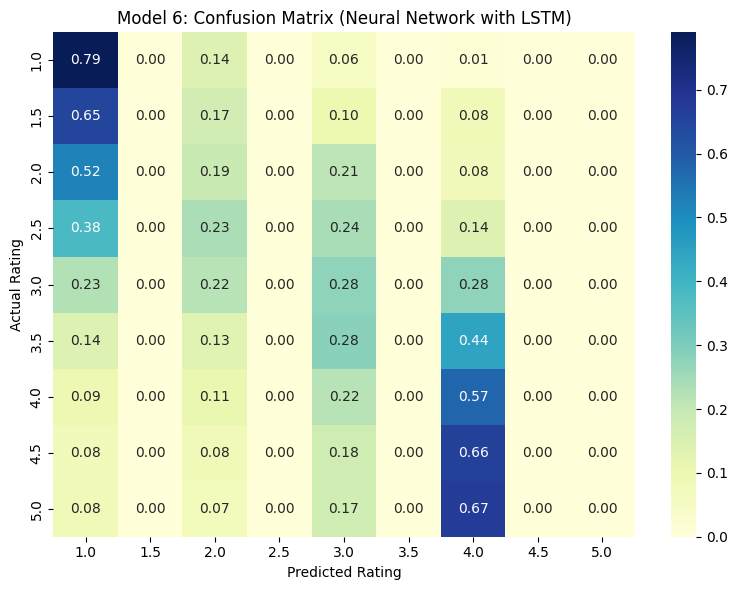

In [83]:
# ============================================
# EVALUATE MODEL 6 (Neural Network with LSTM)
# ============================================
print("=" * 50)
print("MODEL 6 EVALUATION (Neural Network with LSTM)")
print("=" * 50)

# Check if Model 6 has been trained
try:
    import numpy as np
    import pandas as pd
    from sklearn.metrics import accuracy_score, confusion_matrix, classification_report
    import matplotlib.pyplot as plt
    import seaborn as sns
    
    # Get all possible classes
    all_classes = [f"{x:.1f}" for x in np.arange(1.0, 5.1, 0.5)]
    
    # Calculate metrics for Model 6
    # (use test_labels and y_pred_labels from the LSTM training cell)
    accuracy_model6 = accuracy_score(test_labels, y_pred_labels)
    y_test_numeric = np.array([float(x) for x in test_labels])
    y_pred_model6_numeric = np.array([float(x) for x in y_pred_labels])
    
    within_half_model6 = np.abs(y_pred_model6_numeric - y_test_numeric) <= 0.5
    within_one_model6 = np.abs(y_pred_model6_numeric - y_test_numeric) <= 1.0
    acc_within_half_model6 = np.mean(within_half_model6)
    acc_within_one_model6 = np.mean(within_one_model6)
    
    print(f"\nClassification Accuracy: {accuracy_model6:.3f}")
    print(f"Accuracy within ±0.5-star margin: {acc_within_half_model6:.3f}")
    print(f"Accuracy within ±1.0-star margin: {acc_within_one_model6:.3f}")
    
    print("\nClassification Report:")
    print(classification_report(test_labels, y_pred_labels,
                                labels=all_classes, zero_division=0))
    
    # Confusion matrix for Model 6
    cm_model6 = confusion_matrix(test_labels, y_pred_labels,
                                 labels=all_classes, normalize='true')
    plt.figure(figsize=(8, 6))
    sns.heatmap(cm_model6, annot=True, fmt=".2f", cmap="YlGnBu",
                xticklabels=all_classes, yticklabels=all_classes)
    plt.xlabel("Predicted Rating")
    plt.ylabel("Actual Rating")
    plt.title("Model 6: Confusion Matrix (Neural Network with LSTM)")
    plt.tight_layout()
    plt.show()
    
except NameError:
    print("\n⚠️  ERROR: Model 6 predictions (y_pred_labels) or test_labels not found!")
    print("\nPlease ensure you have run the following cells in order:")
    print("  1. Train/Test Split cell (creates train_labels, test_labels)")
    print("  2. Model 6 Training cell (creates model6 and y_pred_labels)")
    print("  3. This evaluation cell")
    print("\nThen re-run this cell.")
except Exception as e:
    print(f"\n⚠️  ERROR: {type(e).__name__}: {e}")
    print("\nPlease check that all prerequisite cells have been run.")


In [76]:
# ============================================
# ADD MODEL 6 TO COMPARISON
# ============================================
# Add Model 6 (Neural Network with LSTM) to the comparison table

try:
    # Check if Model 6 has been trained
    _ = y_pred_model6
    
    # Get all classes
    all_classes = [f"{x:.1f}" for x in np.arange(1.0, 5.1, 0.5)]
    
    # Add Model 6 to comparison using helper function
    if 'add_model_to_comparison' in globals():
        add_model_to_comparison('Model 6 (Neural Network with LSTM)', y_pred_model6, y_test, all_classes)
    else:
        # Manual addition if helper function not available
        from sklearn.metrics import accuracy_score, precision_recall_fscore_support
        
        accuracy_model6 = accuracy_score(y_test, y_pred_model6)
        y_test_numeric = np.array([float(x) for x in y_test])
        y_pred_model6_numeric = np.array([float(x) for x in y_pred_model6])
        
        within_half_model6 = np.abs(y_pred_model6_numeric - y_test_numeric) <= 0.5
        within_one_model6 = np.abs(y_pred_model6_numeric - y_test_numeric) <= 1.0
        acc_within_half_model6 = np.mean(within_half_model6)
        acc_within_one_model6 = np.mean(within_one_model6)
        
        prec_model6, rec_model6, f1_model6, _ = precision_recall_fscore_support(
            y_test, y_pred_model6, labels=all_classes, zero_division=0, average=None
        )
        
        new_row = pd.DataFrame({
            'Model': ['Model 6 (Neural Network with LSTM)'],
            'Exact Accuracy': [accuracy_model6],
            'Accuracy ±0.5': [acc_within_half_model6],
            'Accuracy ±1.0': [acc_within_one_model6],
            'Macro Avg Precision': [np.mean(prec_model6)],
            'Macro Avg Recall': [np.mean(rec_model6)],
            'Macro Avg F1': [np.mean(f1_model6)]
        })
        
        # Add to existing comparison
        global models_comparison
        models_comparison = pd.concat([models_comparison, new_row], ignore_index=True)
        
        print(f"\n✓ Added Model 6 (Neural Network with LSTM) to comparison")
        print(f"  Exact Accuracy: {accuracy_model6:.3f}")
        print(f"  Accuracy ±0.5: {acc_within_half_model6:.3f}")
        print(f"  Accuracy ±1.0: {acc_within_one_model6:.3f}")

except NameError:
    print("\n⚠️  ERROR: Model 6 predictions (y_pred_model6) not found!")
    print("\nPlease ensure you have run the following cells in order:")
    print("  1. Data Augmentation cell (creates X_train_aug, y_train_aug)")
    print("  2. Model 6 Training cell (creates model6 and y_pred_model6)")
    print("  3. Model 6 Evaluation cell")
    print("  4. This comparison cell")
    print("\nThen re-run this cell.")
except Exception as e:
    print(f"\n⚠️  ERROR: {type(e).__name__}: {e}")
    print("\nPlease check that all prerequisite cells have been run.")



✓ Added Model 6 (Neural Network with LSTM) to comparison
  Exact Accuracy: 0.347
  Accuracy ±0.5: 0.466
  Accuracy ±1.0: 0.589


In [77]:
# ============================================
# ADD MODEL 3 TO COMPARISON
# ============================================
# Add Model 3 (Data Augmentation) to the comparison table

try:
    # Check if Model 3 has been trained
    _ = y_pred_model3
    
    # Get all classes
    all_classes = [f"{x:.1f}" for x in np.arange(1.0, 5.1, 0.5)]
    
    # Add Model 3 to comparison using helper function
    if 'add_model_to_comparison' in globals():
        add_model_to_comparison('Model 3 (Data Augmentation)', y_pred_model3, y_test, all_classes)
    else:
        # Manual addition if helper function not available
        from sklearn.metrics import accuracy_score, precision_recall_fscore_support
        
        accuracy_model3 = accuracy_score(y_test, y_pred_model3)
        y_test_numeric = np.array([float(x) for x in y_test])
        y_pred_model3_numeric = np.array([float(x) for x in y_pred_model3])
        
        within_half_model3 = np.abs(y_pred_model3_numeric - y_test_numeric) <= 0.5
        within_one_model3 = np.abs(y_pred_model3_numeric - y_test_numeric) <= 1.0
        acc_within_half_model3 = np.mean(within_half_model3)
        acc_within_one_model3 = np.mean(within_one_model3)
        
        prec_model3, rec_model3, f1_model3, _ = precision_recall_fscore_support(
            y_test, y_pred_model3, labels=all_classes, zero_division=0, average=None
        )
        
        new_row = pd.DataFrame({
            'Model': ['Model 3 (Data Augmentation)'],
            'Exact Accuracy': [accuracy_model3],
            'Accuracy ±0.5': [acc_within_half_model3],
            'Accuracy ±1.0': [acc_within_one_model3],
            'Macro Avg Precision': [np.mean(prec_model3)],
            'Macro Avg Recall': [np.mean(rec_model3)],
            'Macro Avg F1': [np.mean(f1_model3)]
        })
        
        # Add to existing comparison
        global models_comparison
        models_comparison = pd.concat([models_comparison, new_row], ignore_index=True)
        
        print(f"\n✓ Added Model 3 (Data Augmentation) to comparison")
        print(f"  Exact Accuracy: {accuracy_model3:.3f}")
        print(f"  Accuracy ±0.5: {acc_within_half_model3:.3f}")
        print(f"  Accuracy ±1.0: {acc_within_one_model3:.3f}")
        
except NameError:
    print("\n⚠️  ERROR: Model 3 predictions (y_pred_model3) not found!")
    print("\nPlease ensure you have run the following cells in order:")
    print("  1. Data Augmentation cell (creates X_train_aug, y_train_aug)")
    print("  2. Model 3 Training cell (creates model3 and y_pred_model3)")
    print("  3. This comparison cell")
    print("\nThen re-run this cell.")
except Exception as e:
    print(f"\n⚠️  ERROR: {type(e).__name__}: {e}")
    print("\nPlease check that all prerequisite cells have been run.")



✓ Added Model 3 (Data Augmentation) to comparison
  Exact Accuracy: 0.626
  Accuracy ±0.5: 0.751
  Accuracy ±1.0: 0.849


In [78]:
# ============================================
# ADD MODEL 4 TO COMPARISON
# ============================================
# Add Model 4 (XGBoost) to the comparison table

try:
    # Check if Model 4 has been trained
    _ = y_pred_model4
    
    # Get all classes
    all_classes = [f"{x:.1f}" for x in np.arange(1.0, 5.1, 0.5)]
    
    # Add Model 4 to comparison using helper function
    if 'add_model_to_comparison' in globals():
        add_model_to_comparison('Model 4 (XGBoost)', y_pred_model4, y_test, all_classes)
    else:
        # Manual addition if helper function not available
        from sklearn.metrics import accuracy_score, precision_recall_fscore_support
        
        accuracy_model4 = accuracy_score(y_test, y_pred_model4)
        y_test_numeric = np.array([float(x) for x in y_test])
        y_pred_model4_numeric = np.array([float(x) for x in y_pred_model4])
        
        within_half_model4 = np.abs(y_pred_model4_numeric - y_test_numeric) <= 0.5
        within_one_model4 = np.abs(y_pred_model4_numeric - y_test_numeric) <= 1.0
        acc_within_half_model4 = np.mean(within_half_model4)
        acc_within_one_model4 = np.mean(within_one_model4)
        
        prec_model4, rec_model4, f1_model4, _ = precision_recall_fscore_support(
            y_test, y_pred_model4, labels=all_classes, zero_division=0, average=None
        )
        
        new_row = pd.DataFrame({
            'Model': ['Model 4 (XGBoost)'],
            'Exact Accuracy': [accuracy_model4],
            'Accuracy ±0.5': [acc_within_half_model4],
            'Accuracy ±1.0': [acc_within_one_model4],
            'Macro Avg Precision': [np.mean(prec_model4)],
            'Macro Avg Recall': [np.mean(rec_model4)],
            'Macro Avg F1': [np.mean(f1_model4)]
        })
        
        # Add to existing comparison
        global models_comparison
        models_comparison = pd.concat([models_comparison, new_row], ignore_index=True)
        
        print(f"\n✓ Added Model 4 (XGBoost) to comparison")
        print(f"  Exact Accuracy: {accuracy_model4:.3f}")
        print(f"  Accuracy ±0.5: {acc_within_half_model4:.3f}")
        print(f"  Accuracy ±1.0: {acc_within_one_model4:.3f}")

except NameError:
    print("\n⚠️  ERROR: Model 4 predictions (y_pred_model4) not found!")
    print("\nPlease ensure you have run the following cells in order:")
    print("  1. Data Augmentation cell (creates X_train_aug, y_train_aug)")
    print("  2. Model 4 Training cell (creates model4 and y_pred_model4)")
    print("  3. Model 4 Evaluation cell")
    print("  4. This comparison cell")
    print("\nThen re-run this cell.")
except Exception as e:
    print(f"\n⚠️  ERROR: {type(e).__name__}: {e}")
    print("\nPlease check that all prerequisite cells have been run.")



✓ Added Model 4 (XGBoost) to comparison
  Exact Accuracy: 0.680
  Accuracy ±0.5: 0.765
  Accuracy ±1.0: 0.851


## Model Comparison

Compare all models side-by-side. Add new models below as you experiment.

MODEL COMPARISON SUMMARY

                             Model  Exact Accuracy  Accuracy ±0.5  Accuracy ±1.0  Macro Avg Precision  Macro Avg Recall  Macro Avg F1
                Model 1 (Baseline)        0.430858       0.618155       0.780945             0.235903          0.222916      0.205428
     Model 2 (Random Oversampling)        0.308327       0.552638       0.720180             0.218657          0.222053      0.215364
       Model 3 (Data Augmentation)        0.625906       0.750938       0.849212             0.581143          0.593430      0.579487
                 Model 4 (XGBoost)        0.680170       0.765191       0.850713             0.705154          0.649868      0.662396
           Model 5 (Random Forest)        0.690173       0.774694       0.847212             0.684013          0.689683      0.680290
Model 6 (Neural Network with LSTM)        0.347087       0.466367       0.589147             0.038565          0.111111      0.057257

DETAILED PER-CLASS COMPARISON

Per-

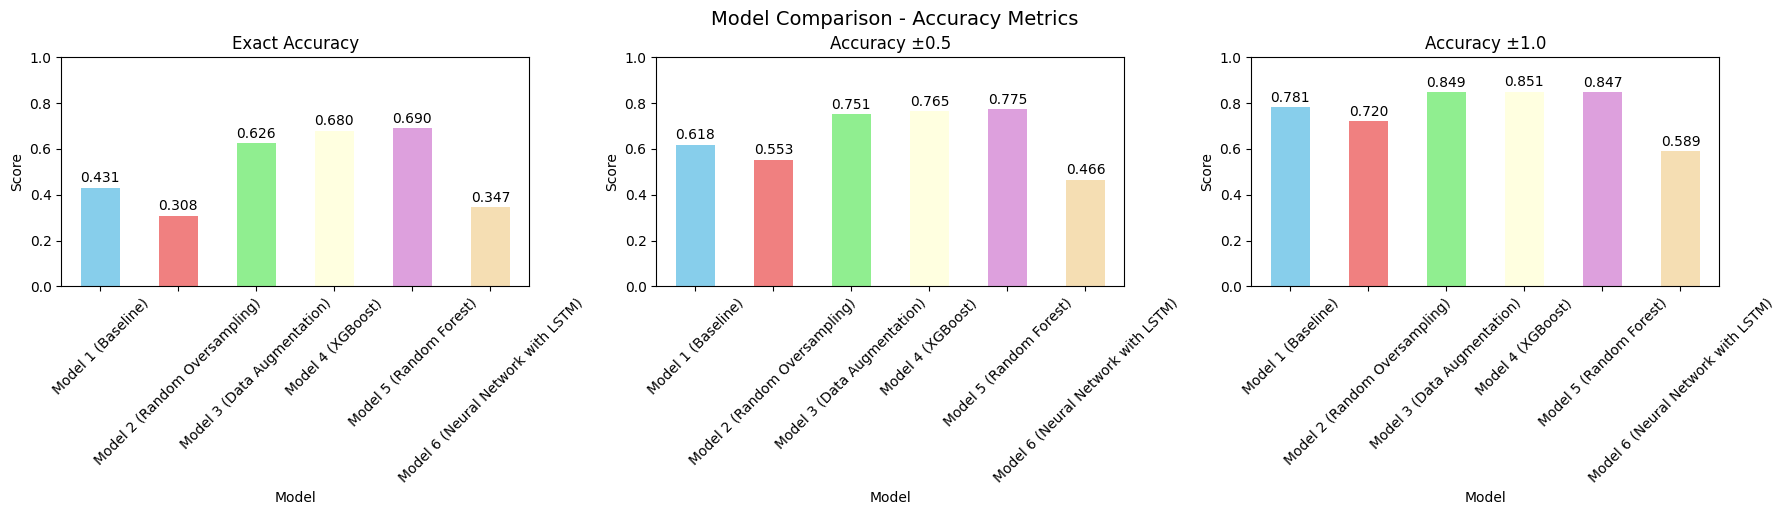


NOTE: Add more models below as you experiment


In [79]:
# ============================================
# MODEL COMPARISON TABLE
# ============================================
print("=" * 80)
print("MODEL COMPARISON SUMMARY")
print("=" * 80)

# Calculate per-class metrics for all models
from sklearn.metrics import precision_recall_fscore_support

# Get all classes
all_classes = [f"{x:.1f}" for x in np.arange(1.0, 5.1, 0.5)]

# Calculate metrics for Model 1
prec_model1, rec_model1, f1_model1, _ = precision_recall_fscore_support(
    y_test, y_pred_model1, labels=all_classes, zero_division=0, average=None
)

# Calculate metrics for Model 2
prec_model2, rec_model2, f1_model2, _ = precision_recall_fscore_support(
    y_test, y_pred_model2, labels=all_classes, zero_division=0, average=None
)

# Calculate metrics for Model 3 (if available)
try:
    _ = y_pred_model3  # Check if Model 3 exists
    _ = accuracy_model3  # Check if Model 3 evaluation metrics exist
    _ = acc_within_half_model3
    _ = acc_within_one_model3
    prec_model3, rec_model3, f1_model3, _ = precision_recall_fscore_support(
        y_test, y_pred_model3, labels=all_classes, zero_division=0, average=None
    )
    model3_available = True
except NameError:
    print("⚠️  WARNING: Model 3 predictions or evaluation metrics not found.")
    print("Please run the Model 3 training and evaluation cells first.")
    print("Comparison will include only Models 1 and 2.\n")
    model3_available = False

# Calculate metrics for Model 4 (if available)
try:
    _ = y_pred_model4  # Check if Model 4 exists
    _ = accuracy_model4  # Check if Model 4 evaluation metrics exist
    _ = acc_within_half_model4
    _ = acc_within_one_model4
    prec_model4, rec_model4, f1_model4, _ = precision_recall_fscore_support(
        y_test, y_pred_model4, labels=all_classes, zero_division=0, average=None
    )
    model4_available = True
except NameError:
    print("⚠️  WARNING: Model 4 predictions or evaluation metrics not found.")
    print("Please run the Model 4 training and evaluation cells first.")
    model4_available = False

# Calculate metrics for Model 5 (if available)
try:
    _ = y_pred_model5  # Check if Model 5 exists
    _ = accuracy_model5  # Check if Model 5 evaluation metrics exist
    _ = acc_within_half_model5
    _ = acc_within_one_model5
    prec_model5, rec_model5, f1_model5, _ = precision_recall_fscore_support(
        y_test, y_pred_model5, labels=all_classes, zero_division=0, average=None
    )
    model5_available = True
except NameError:
    print("⚠️  WARNING: Model 5 predictions or evaluation metrics not found.")
    print("Please run the Model 5 training and evaluation cells first.")
    model5_available = False

# Calculate metrics for Model 6 (if available)
try:
    _ = y_pred_model6  # Check if Model 6 exists
    _ = accuracy_model6  # Check if Model 6 evaluation metrics exist
    _ = acc_within_half_model6
    _ = acc_within_one_model6
    prec_model6, rec_model6, f1_model6, _ = precision_recall_fscore_support(
        y_test, y_pred_model6, labels=all_classes, zero_division=0, average=None
    )
    model6_available = True
except NameError:
    print("⚠️  WARNING: Model 6 predictions or evaluation metrics not found.")
    print("Please run the Model 6 training and evaluation cells first.")
    model6_available = False

# Create comparison DataFrame
if model3_available and model4_available and model5_available and model6_available:
    comparison_data = {
        'Model': ['Model 1 (Baseline)', 'Model 2 (Random Oversampling)', 'Model 3 (Data Augmentation)', 'Model 4 (XGBoost)', 'Model 5 (Random Forest)', 'Model 6 (Neural Network with LSTM)'],
        'Exact Accuracy': [accuracy_model1, accuracy_model2, accuracy_model3, accuracy_model4, accuracy_model5, accuracy_model6],
        'Accuracy ±0.5': [acc_within_half_model1, acc_within_half_model2, acc_within_half_model3, acc_within_half_model4, acc_within_half_model5, acc_within_half_model6],
        'Accuracy ±1.0': [acc_within_one_model1, acc_within_one_model2, acc_within_one_model3, acc_within_one_model4, acc_within_one_model5, acc_within_one_model6],
        'Macro Avg Precision': [np.mean(prec_model1), np.mean(prec_model2), np.mean(prec_model3), np.mean(prec_model4), np.mean(prec_model5), np.mean(prec_model6)],
        'Macro Avg Recall': [np.mean(rec_model1), np.mean(rec_model2), np.mean(rec_model3), np.mean(rec_model4), np.mean(rec_model5), np.mean(rec_model6)],
        'Macro Avg F1': [np.mean(f1_model1), np.mean(f1_model2), np.mean(f1_model3), np.mean(f1_model4), np.mean(f1_model5), np.mean(f1_model6)]
    }
elif model3_available and model4_available and model5_available:
    comparison_data = {
        'Model': ['Model 1 (Baseline)', 'Model 2 (Random Oversampling)', 'Model 3 (Data Augmentation)', 'Model 4 (XGBoost)', 'Model 5 (Random Forest)'],
        'Exact Accuracy': [accuracy_model1, accuracy_model2, accuracy_model3, accuracy_model4, accuracy_model5],
        'Accuracy ±0.5': [acc_within_half_model1, acc_within_half_model2, acc_within_half_model3, acc_within_half_model4, acc_within_half_model5],
        'Accuracy ±1.0': [acc_within_one_model1, acc_within_one_model2, acc_within_one_model3, acc_within_one_model4, acc_within_one_model5],
        'Macro Avg Precision': [np.mean(prec_model1), np.mean(prec_model2), np.mean(prec_model3), np.mean(prec_model4), np.mean(prec_model5)],
        'Macro Avg Recall': [np.mean(rec_model1), np.mean(rec_model2), np.mean(rec_model3), np.mean(rec_model4), np.mean(rec_model5)],
        'Macro Avg F1': [np.mean(f1_model1), np.mean(f1_model2), np.mean(f1_model3), np.mean(f1_model4), np.mean(f1_model5)]
    }
elif model3_available and model4_available:
    comparison_data = {
        'Model': ['Model 1 (Baseline)', 'Model 2 (Random Oversampling)', 'Model 3 (Data Augmentation)', 'Model 4 (XGBoost)'],
        'Exact Accuracy': [accuracy_model1, accuracy_model2, accuracy_model3, accuracy_model4],
        'Accuracy ±0.5': [acc_within_half_model1, acc_within_half_model2, acc_within_half_model3, acc_within_half_model4],
        'Accuracy ±1.0': [acc_within_one_model1, acc_within_one_model2, acc_within_one_model3, acc_within_one_model4],
        'Macro Avg Precision': [np.mean(prec_model1), np.mean(prec_model2), np.mean(prec_model3), np.mean(prec_model4)],
        'Macro Avg Recall': [np.mean(rec_model1), np.mean(rec_model2), np.mean(rec_model3), np.mean(rec_model4)],
        'Macro Avg F1': [np.mean(f1_model1), np.mean(f1_model2), np.mean(f1_model3), np.mean(f1_model4)]
    }
elif model3_available:
    comparison_data = {
        'Model': ['Model 1 (Baseline)', 'Model 2 (Random Oversampling)', 'Model 3 (Data Augmentation)'],
        'Exact Accuracy': [accuracy_model1, accuracy_model2, accuracy_model3],
        'Accuracy ±0.5': [acc_within_half_model1, acc_within_half_model2, acc_within_half_model3],
        'Accuracy ±1.0': [acc_within_one_model1, acc_within_one_model2, acc_within_one_model3],
        'Macro Avg Precision': [np.mean(prec_model1), np.mean(prec_model2), np.mean(prec_model3)],
        'Macro Avg Recall': [np.mean(rec_model1), np.mean(rec_model2), np.mean(rec_model3)],
        'Macro Avg F1': [np.mean(f1_model1), np.mean(f1_model2), np.mean(f1_model3)]
    }
else:
    comparison_data = {
        'Model': ['Model 1 (Baseline)', 'Model 2 (Random Oversampling)'],
        'Exact Accuracy': [accuracy_model1, accuracy_model2],
        'Accuracy ±0.5': [acc_within_half_model1, acc_within_half_model2],
        'Accuracy ±1.0': [acc_within_one_model1, acc_within_one_model2],
        'Macro Avg Precision': [np.mean(prec_model1), np.mean(prec_model2)],
        'Macro Avg Recall': [np.mean(rec_model1), np.mean(rec_model2)],
        'Macro Avg F1': [np.mean(f1_model1), np.mean(f1_model2)]
    }

comparison_df = pd.DataFrame(comparison_data)
print("\n" + comparison_df.to_string(index=False))

# Store results for future model additions
models_comparison = comparison_df.copy()

print("\n" + "=" * 80)
print("DETAILED PER-CLASS COMPARISON")
print("=" * 80)

# Per-class comparison
if model3_available and model4_available and model5_available and model6_available:
    per_class_comparison = pd.DataFrame({
        'Class': all_classes,
        'Model 1 Precision': prec_model1,
        'Model 1 Recall': rec_model1,
        'Model 1 F1': f1_model1,
        'Model 2 Precision': prec_model2,
        'Model 2 Recall': rec_model2,
        'Model 2 F1': f1_model2,
        'Model 3 Precision': prec_model3,
        'Model 3 Recall': rec_model3,
        'Model 3 F1': f1_model3,
        'Model 4 Precision': prec_model4,
        'Model 4 Recall': rec_model4,
        'Model 4 F1': f1_model4,
        'Model 5 Precision': prec_model5,
        'Model 5 Recall': rec_model5,
        'Model 5 F1': f1_model5,
        'Model 6 Precision': prec_model6,
        'Model 6 Recall': rec_model6,
        'Model 6 F1': f1_model6,
    })
elif model3_available and model4_available and model5_available:
    per_class_comparison = pd.DataFrame({
        'Class': all_classes,
        'Model 1 Precision': prec_model1,
        'Model 1 Recall': rec_model1,
        'Model 1 F1': f1_model1,
        'Model 2 Precision': prec_model2,
        'Model 2 Recall': rec_model2,
        'Model 2 F1': f1_model2,
        'Model 3 Precision': prec_model3,
        'Model 3 Recall': rec_model3,
        'Model 3 F1': f1_model3,
        'Model 4 Precision': prec_model4,
        'Model 4 Recall': rec_model4,
        'Model 4 F1': f1_model4,
        'Model 5 Precision': prec_model5,
        'Model 5 Recall': rec_model5,
        'Model 5 F1': f1_model5,
    })
elif model3_available and model4_available:
    per_class_comparison = pd.DataFrame({
        'Class': all_classes,
        'Model 1 Precision': prec_model1,
        'Model 1 Recall': rec_model1,
        'Model 1 F1': f1_model1,
        'Model 2 Precision': prec_model2,
        'Model 2 Recall': rec_model2,
        'Model 2 F1': f1_model2,
        'Model 3 Precision': prec_model3,
        'Model 3 Recall': rec_model3,
        'Model 3 F1': f1_model3,
        'Model 4 Precision': prec_model4,
        'Model 4 Recall': rec_model4,
        'Model 4 F1': f1_model4,
    })
elif model3_available:
    per_class_comparison = pd.DataFrame({
        'Class': all_classes,
        'Model 1 Precision': prec_model1,
        'Model 1 Recall': rec_model1,
        'Model 1 F1': f1_model1,
        'Model 2 Precision': prec_model2,
        'Model 2 Recall': rec_model2,
        'Model 2 F1': f1_model2,
        'Model 3 Precision': prec_model3,
        'Model 3 Recall': rec_model3,
        'Model 3 F1': f1_model3,
    })
else:
    per_class_comparison = pd.DataFrame({
        'Class': all_classes,
        'Model 1 Precision': prec_model1,
        'Model 1 Recall': rec_model1,
        'Model 1 F1': f1_model1,
        'Model 2 Precision': prec_model2,
        'Model 2 Recall': rec_model2,
        'Model 2 F1': f1_model2,
    })

print("\nPer-Class Metrics:")
print(per_class_comparison.round(3).to_string(index=False))

# Visualize comparison
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ['Exact Accuracy', 'Accuracy ±0.5', 'Accuracy ±1.0']
# Set colors based on number of models
if model3_available and model4_available and model5_available and model6_available:
    colors = ['skyblue', 'lightcoral', 'lightgreen', 'lightyellow', 'plum', 'wheat']
elif model3_available and model4_available and model5_available:
    colors = ['skyblue', 'lightcoral', 'lightgreen', 'lightyellow', 'plum']
elif model3_available and model4_available:
    colors = ['skyblue', 'lightcoral', 'lightgreen', 'lightyellow']
elif model3_available:
    colors = ['skyblue', 'lightcoral', 'lightgreen']
elif model4_available:
    colors = ['skyblue', 'lightcoral', 'lightyellow']
elif model5_available:
    colors = ['skyblue', 'lightcoral', 'plum']
elif model6_available:
    colors = ['skyblue', 'lightcoral', 'wheat']
else:
    colors = ['skyblue', 'lightcoral']

for idx, metric in enumerate(metrics):
    comparison_df.plot(x='Model', y=metric, kind='bar', ax=axes[idx], 
                      color=colors, legend=False)
    axes[idx].set_title(metric)
    axes[idx].set_ylabel('Score')
    axes[idx].set_ylim([0, 1])
    axes[idx].tick_params(axis='x', rotation=45)
    for i, v in enumerate(comparison_df[metric]):
        axes[idx].text(i, v + 0.01, f'{v:.3f}', ha='center', va='bottom')

plt.tight_layout()
plt.suptitle('Model Comparison - Accuracy Metrics', y=1.02, fontsize=14)
plt.show()

print("\n" + "=" * 80)
print("NOTE: Add more models below as you experiment")
print("=" * 80)

In [80]:
"""## Adding More Models (Template)

To add a new model (e.g., Model 3), use the helper function in Cell 28:

1. **Train your new model** in a new cell
2. **Get predictions** from your model
3. **Use the helper function** to add it to the comparison table

See Cell 28 for the `add_model_to_comparison()` helper function.
"""

'## Adding More Models (Template)\n\nTo add a new model (e.g., Model 3), use the helper function in Cell 28:\n\n1. **Train your new model** in a new cell\n2. **Get predictions** from your model\n3. **Use the helper function** to add it to the comparison table\n\nSee Cell 28 for the `add_model_to_comparison()` helper function.\n'

In [81]:
# ============================================
# HELPER FUNCTION: Update Model Comparison
# ============================================
# Use this function to easily add new models to the comparison table
def add_model_to_comparison(model_name, y_pred, y_test, all_classes):
    """
    Helper function to add a new model to the comparison table.
    
    Parameters:
    - model_name: str, name of the model (e.g., 'Model 3 (RandomForest)')
    - y_pred: array-like, predictions from the model
    - y_test: array-like, true labels
    - all_classes: list, all possible class labels
    """
    from sklearn.metrics import accuracy_score, precision_recall_fscore_support
    
    # Calculate metrics
    accuracy = accuracy_score(y_test, y_pred)
    y_test_numeric = np.array([float(x) for x in y_test])
    y_pred_numeric = np.array([float(x) for x in y_pred])
    
    within_half = np.abs(y_pred_numeric - y_test_numeric) <= 0.5
    within_one = np.abs(y_pred_numeric - y_test_numeric) <= 1.0
    acc_within_half = np.mean(within_half)
    acc_within_one = np.mean(within_one)
    
    prec, rec, f1, _ = precision_recall_fscore_support(
        y_test, y_pred, labels=all_classes, zero_division=0, average=None
    )
    
    # Create new row
    new_row = pd.DataFrame({
        'Model': [model_name],
        'Exact Accuracy': [accuracy],
        'Accuracy ±0.5': [acc_within_half],
        'Accuracy ±1.0': [acc_within_one],
        'Macro Avg Precision': [np.mean(prec)],
        'Macro Avg Recall': [np.mean(rec)],
        'Macro Avg F1': [np.mean(f1)]
    })
    
    # Add to comparison
    global models_comparison
    models_comparison = pd.concat([models_comparison, new_row], ignore_index=True)
    
    print(f"\n✓ Added {model_name} to comparison")
    print(f"  Exact Accuracy: {accuracy:.3f}")
    print(f"  Accuracy ±0.5: {acc_within_half:.3f}")
    print(f"  Accuracy ±1.0: {acc_within_one:.3f}")
    
    return new_row

print("Helper function 'add_model_to_comparison()' is ready to use!")
print("\nExample usage:")
print("  add_model_to_comparison('Model 3 (RandomForest)', y_pred_model3, y_test, all_classes)")


Helper function 'add_model_to_comparison()' is ready to use!

Example usage:
  add_model_to_comparison('Model 3 (RandomForest)', y_pred_model3, y_test, all_classes)
